# How are in-demand skills trending for Data Analysts, Data Scientists, and Data Engineers?

#### Methodology
1. Aggregate monthly skill counts for Data Analyst, Data Scientist, and Data Engineer roles in Australia.
2. Re-analyze the same trends as a percentage of total monthly job postings.
3. Plot the monthly skill demand for the combined target roles.


## Import Libraries and Data

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## Group the Skills by Month

Select job postings for Data Analyst, Data Scientist, and Data Engineer roles in Australia. Then extract the month from each job's posting date. Next, explode the skills column so each skill gets its own row for monthly analysis.


In [2]:
# Filter for Data Analyst, Data Scientist, Data Engineer in Australia
df_filtered = df[
    (df['job_title_short'].isin(['Data Analyst', 'Data Scientist', 'Data Engineer'])) &
    (df['job_country'].isin(['Australia']))
].copy()

df_filtered['job_posted_month_no'] = df_filtered['job_posted_date'].dt.month

# Explode job_skills column
df_exploded = df_filtered.explode('job_skills')


### Pivot in Prep for Plotting

Create a pivot table from the `filtered data`, setting 'month' as the index, `job_skills` as the columns, and fills missing entries with zero.

In [3]:
# Group by month and job_skills
df_filtered_pivot = df_exploded.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)

df_filtered_pivot

job_skills,airflow,alteryx,angular,ansible,apl,asana,asp.net,asp.net core,assembly,atlassian,...,vmware,vue,vue.js,watson,webex,windows,wire,word,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,98,25,1,20,0,3,0,0,0,10,...,4,0,0,0,0,18,1,30,2,2
2,52,13,0,11,0,2,0,0,0,0,...,7,0,2,0,0,5,1,14,2,1
3,43,6,0,10,0,0,0,0,1,6,...,1,0,1,1,0,11,0,16,3,4
4,36,14,0,8,0,0,1,0,0,5,...,5,0,0,0,0,9,0,13,3,1
5,41,6,1,5,0,0,2,1,0,7,...,3,0,1,0,1,3,0,6,1,0
6,45,11,0,5,1,0,0,0,1,4,...,2,0,0,0,0,2,0,11,0,0
7,44,11,0,6,0,0,0,0,1,4,...,5,0,0,0,0,6,0,18,0,1
8,59,9,0,13,0,0,0,0,1,7,...,3,1,1,2,0,4,0,29,2,1
9,47,18,0,5,0,0,0,0,0,1,...,4,0,0,0,0,3,0,19,1,0


#### Sort columns by count and change month numbers to names

It adds a new row labeled `Total` that sums up counts across all months for each skill. Finally, it reorders the columns based on the total counts, displaying them from highest to lowest, and shows the updated pivot table. 

In [4]:
# sorts by count
df_filtered_pivot.loc['Total'] = df_filtered_pivot.sum()
df_filtered_pivot = df_filtered_pivot[df_filtered_pivot.loc['Total'].sort_values(ascending=False).index]
df_filtered_pivot = df_filtered_pivot.drop('Total')

df_filtered_pivot

job_skills,sql,python,azure,aws,spark,power bi,databricks,r,tableau,snowflake,...,webex,next.js,vue,clickup,monday.com,asp.net core,npm,symfony,svelte,symphony
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,678,542,344,401,251,123,151,138,152,149,...,0,0,0,0,0,0,0,0,0,1
2,301,259,175,187,112,72,78,63,65,67,...,0,0,0,0,1,0,0,0,1,0
3,311,225,186,180,99,72,75,60,75,62,...,0,0,0,0,0,0,0,0,0,0
4,262,245,138,159,91,64,68,63,46,60,...,0,0,0,0,0,0,0,0,0,0
5,230,181,122,136,84,52,65,44,34,44,...,1,0,0,0,0,1,0,0,0,0
6,267,216,139,124,99,74,70,49,56,59,...,0,0,0,0,0,0,0,0,0,0
7,361,286,182,154,76,112,78,65,82,71,...,0,1,0,0,0,0,1,0,0,0
8,397,334,206,164,119,106,103,72,93,90,...,0,0,1,0,0,0,0,0,0,0
9,409,320,182,150,105,134,86,114,78,75,...,0,0,0,0,0,0,0,0,0,0


## Plot the Monthly Skill Counts

Plot a line chart of the top 5 skills across the combined target data roles in Australia, indexed by month.


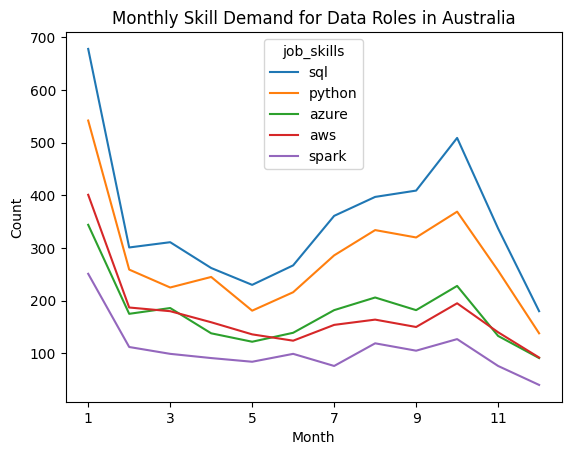

In [5]:
df_filtered_pivot.iloc[:, :5].plot(kind='line')

plt.title('Monthly Skill Demand for Data Roles in Australia')
plt.ylabel('Count')
plt.xlabel('Month')
plt.show()


This is good but totals can be misleading without context. Percentages clarify relationships within the whole, giving a more accurate comparison.

## Calculate Percentage of Total Jobs

Calculates the total number of entries for each month in `df_DA` by grouping the data by 'month' and counting the number of occurrences in each group, storing the results in `DA_totals`. This is needed to compute the percentages.

In [6]:
# Get monthly totals
job_totals = df_filtered.groupby('job_posted_month_no').size()

job_totals

job_posted_month_no
1     1125
2      519
3      529
4      509
5      386
6      484
7      616
8      735
9      721
10     881
11     652
12     338
dtype: int64

This code converts monthly skill counts into percentages by dividing each month's skill counts by the total number of Australia job postings from the target roles in that month.


In [7]:
# Divide monthly skill counts by monthly total job postings
df_filtered_percent = df_filtered_pivot.iloc[:12].div(job_totals/100, axis=0)

# changes month number to month name
df_filtered_percent = df_filtered_percent.reset_index()
df_filtered_percent['job_posted_month'] = df_filtered_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_filtered_percent = df_filtered_percent.set_index('job_posted_month')
df_filtered_percent = df_filtered_percent.drop(columns='job_posted_month_no')

df_filtered_percent


job_skills,sql,python,azure,aws,spark,power bi,databricks,r,tableau,snowflake,...,webex,next.js,vue,clickup,monday.com,asp.net core,npm,symfony,svelte,symphony
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,60.266667,48.177778,30.577778,35.644444,22.311111,10.933333,13.422222,12.266667,13.511111,13.244444,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.088889
Feb,57.996146,49.903661,33.718690,36.030829,21.579961,13.872832,15.028902,12.138728,12.524085,12.909441,...,0.000000,0.000000,0.000000,0.000000,0.192678,0.000000,0.000000,0.000000,0.192678,0.000000
Mar,58.790170,42.533081,35.160681,34.026465,18.714556,13.610586,14.177694,11.342155,14.177694,11.720227,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,51.473477,48.133595,27.111984,31.237721,17.878193,12.573674,13.359528,12.377210,9.037328,11.787819,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,59.585492,46.891192,31.606218,35.233161,21.761658,13.471503,16.839378,11.398964,8.808290,11.398964,...,0.259067,0.000000,0.000000,0.000000,0.000000,0.259067,0.000000,0.000000,0.000000,0.000000
Jun,55.165289,44.628099,28.719008,25.619835,20.454545,15.289256,14.462810,10.123967,11.570248,12.190083,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,58.603896,46.428571,29.545455,25.000000,12.337662,18.181818,12.662338,10.551948,13.311688,11.525974,...,0.000000,0.162338,0.000000,0.000000,0.000000,0.000000,0.162338,0.000000,0.000000,0.000000
Aug,54.013605,45.442177,28.027211,22.312925,16.190476,14.421769,14.013605,9.795918,12.653061,12.244898,...,0.000000,0.000000,0.136054,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,56.726768,44.382802,25.242718,20.804438,14.563107,18.585298,11.927878,15.811373,10.818308,10.402219,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Plot Monthly Skill Demand as Percentages

Creates a line plot for the top five skills across the combined target data roles, shown as percentages of total monthly job postings.


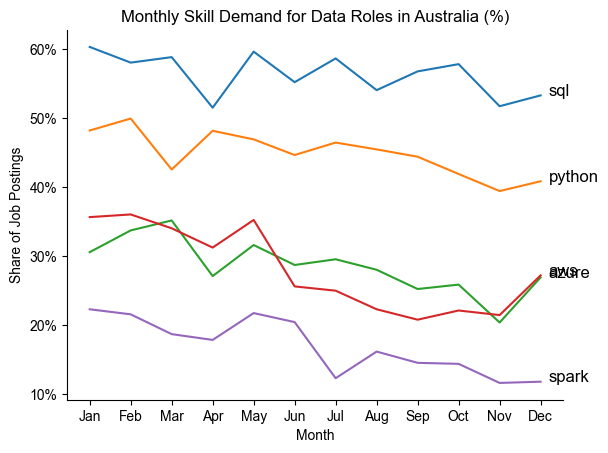

In [8]:
from matplotlib.ticker import PercentFormatter

df_plot = df_filtered_percent.iloc[:, :5]
sns.lineplot(data=df_plot, dashes=False, legend='full', palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

plt.title('Monthly Skill Demand for Data Roles in Australia (%)')
plt.ylabel('Share of Job Postings')
plt.xlabel('Month')
plt.legend().remove()
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i], color='black')

plt.show()


## Australia Trend View
Visualizing the percentage trends of the top skills for the selected data roles in Australia.


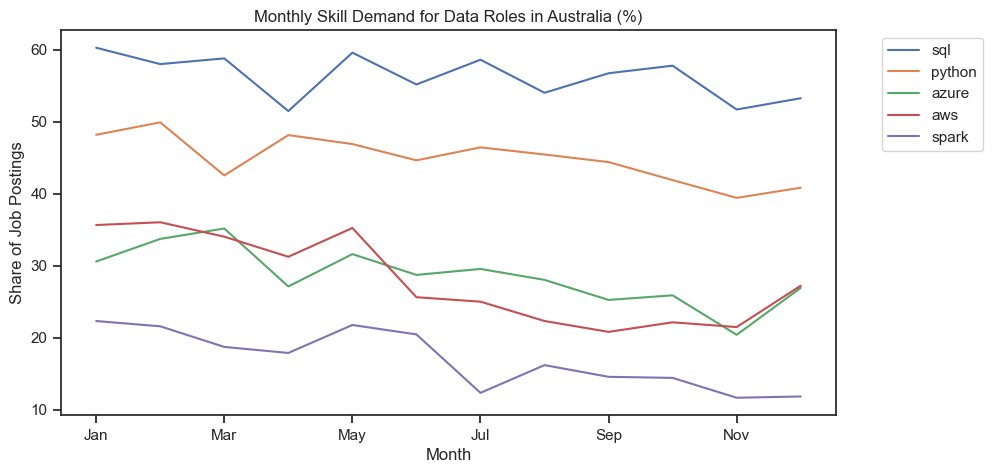

In [9]:
countries = ['Australia']

for country in countries:
    df_country = df_exploded[df_exploded['job_country'] == country].copy()
    country_job_totals = df_filtered[df_filtered['job_country'] == country].groupby('job_posted_month_no').size()
    df_country_pivot = df_country.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)
    df_country_percent = df_country_pivot.div(country_job_totals/100, axis=0)

    df_country_percent.loc['Total'] = df_country_percent.sum()
    df_country_percent = df_country_percent[df_country_percent.loc['Total'].sort_values(ascending=False).index]
    df_country_percent = df_country_percent.drop('Total')

    df_country_percent = df_country_percent.reset_index()
    df_country_percent['job_posted_month'] = df_country_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
    df_country_percent = df_country_percent.set_index('job_posted_month')
    df_country_percent = df_country_percent.drop(columns='job_posted_month_no')

    ax = df_country_percent.iloc[:, :5].plot(kind='line', figsize=(10, 5))
    plt.title(f'Monthly Skill Demand for Data Roles in {country} (%)')
    plt.ylabel('Share of Job Postings')
    plt.xlabel('Month')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()
